In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
from scipy.stats import ttest_ind

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/inventory_project")

BASE_PROJECT = "/content/drive/MyDrive/inventory_project"
DB_PATH = os.path.join(BASE_PROJECT, "inventory.db")
LOG_PATH = os.path.join(BASE_PROJECT, "logs") # Define a directory for logs
LOG_FILE_PATH = os.path.join(LOG_PATH, "get_vendor_summary.log")

Mounted at /content/drive


In [3]:
#creating a database connection
conn = sqlite3.connect(DB_PATH)

#fetching vendor summary data
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,vendornumber,vendorname,brand,description,purchaseprice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchasesRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [4]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendornumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
purchaseprice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


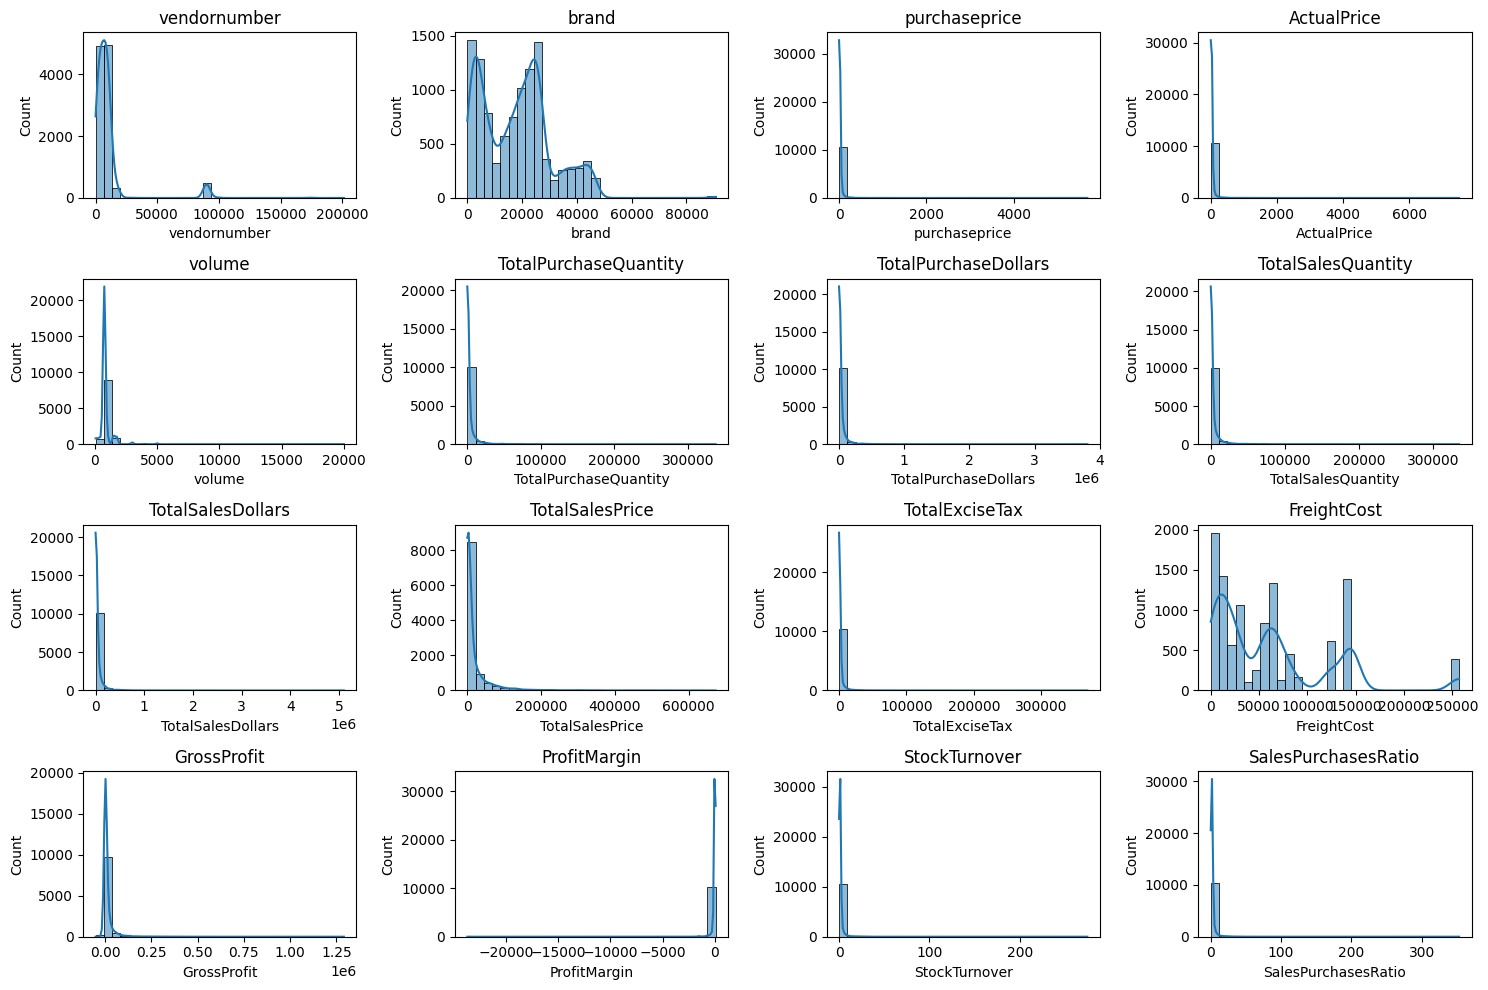

In [5]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

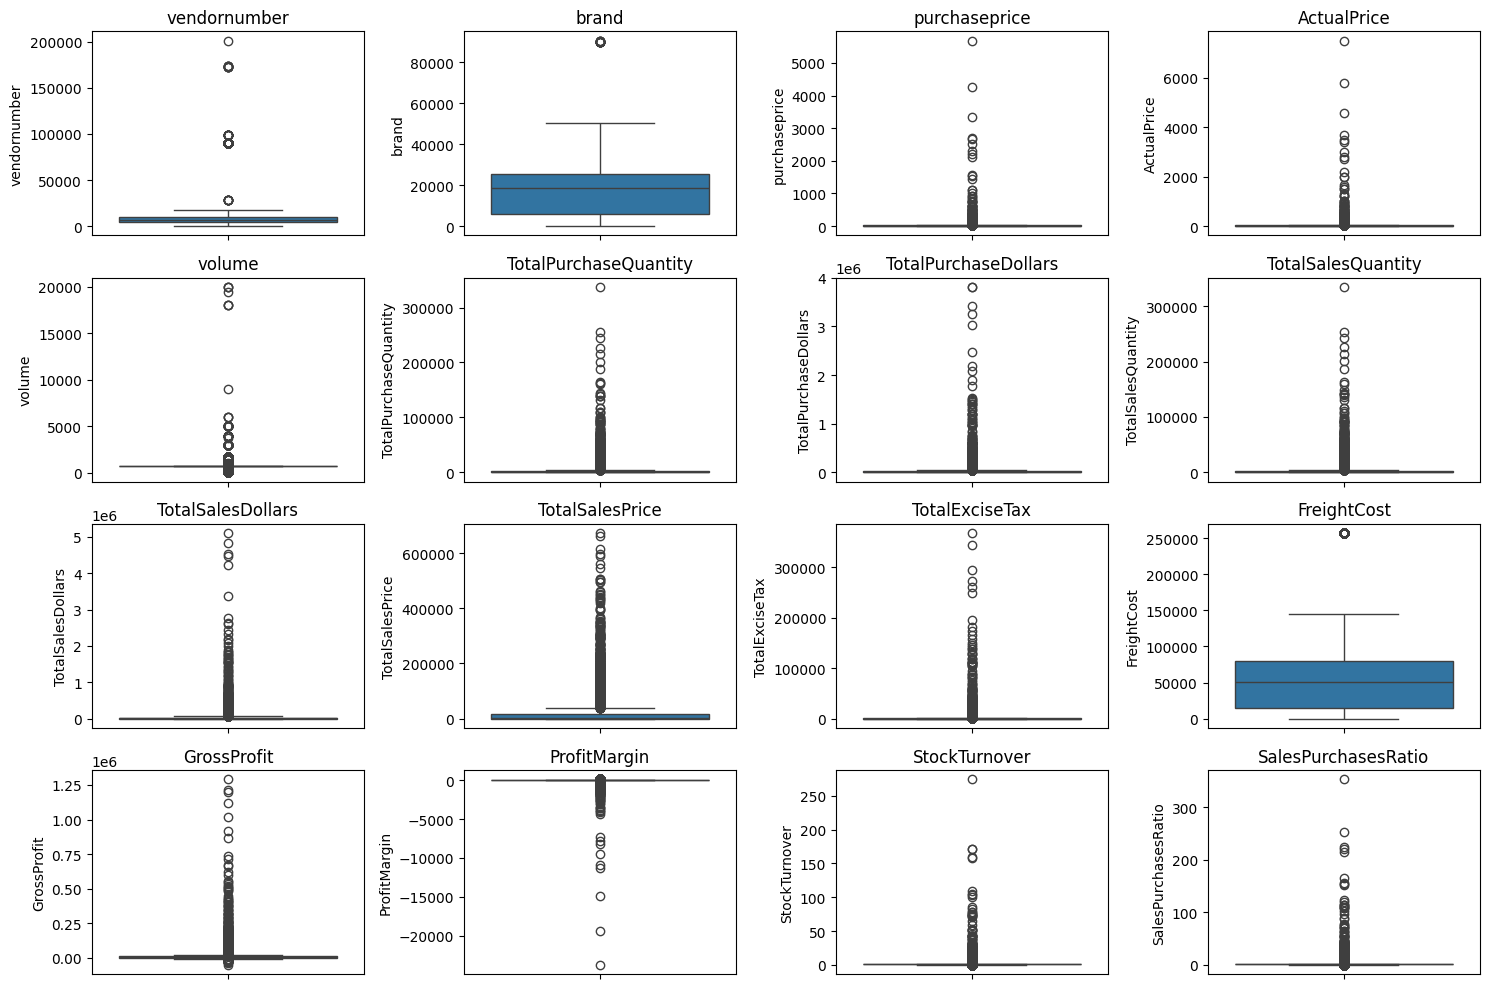

In [6]:
# Outlier Detection with BoxPlots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [7]:
# Let's filter the data by removing inconsistencies
df = pd.read_sql_query(""" SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

df

,vendornumber,vendorname,brand,description,purchaseprice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchasesRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


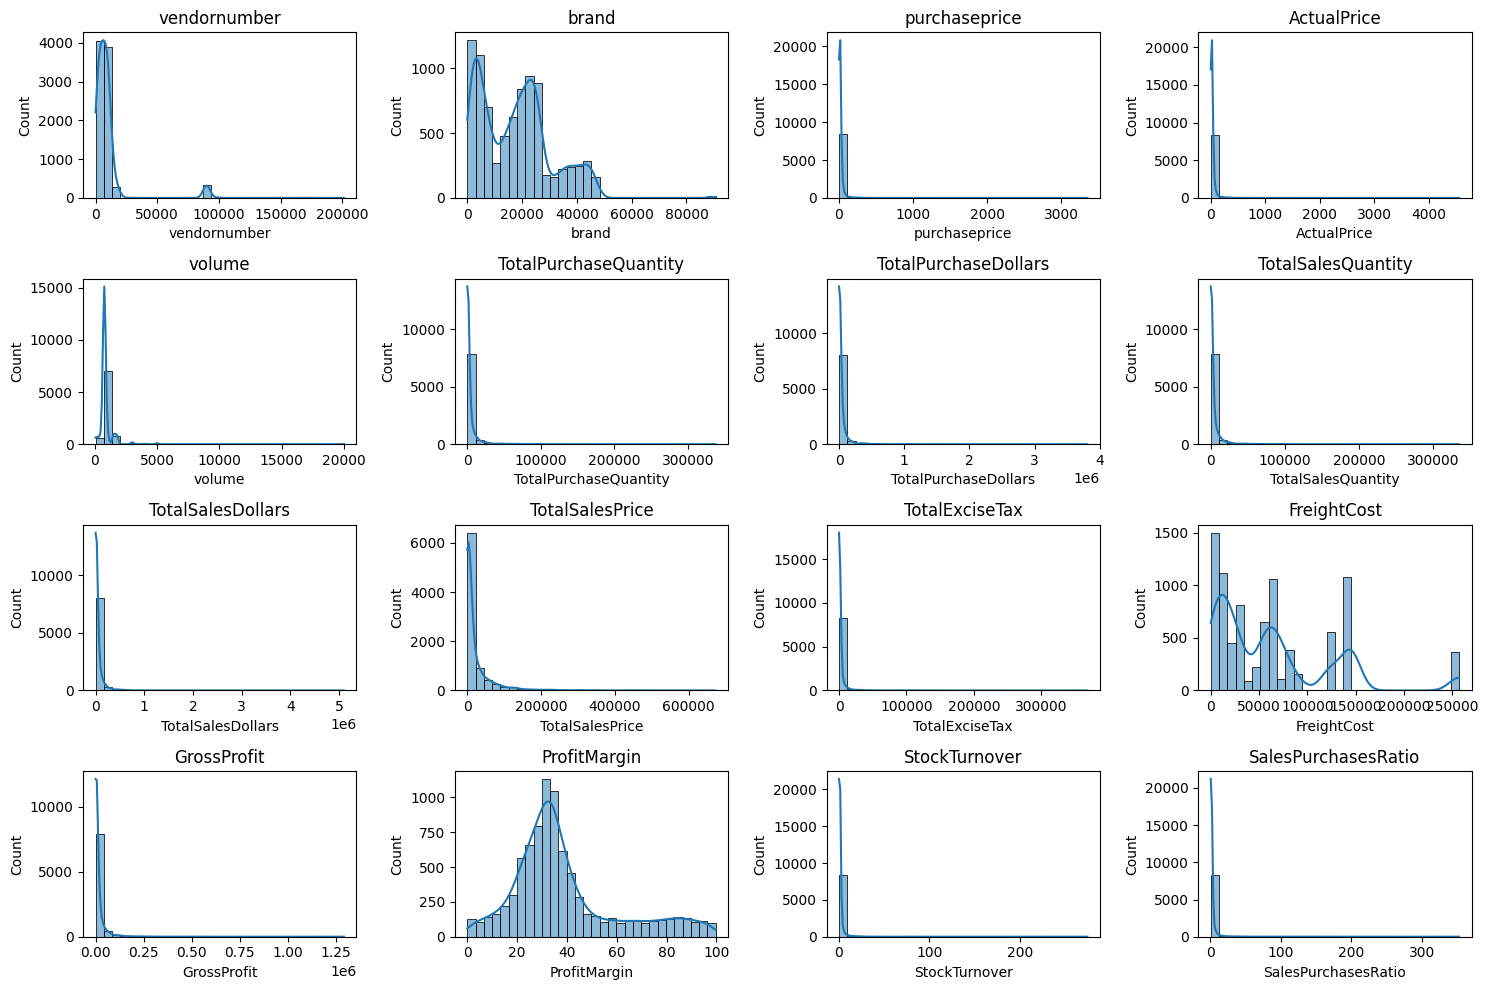

In [8]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

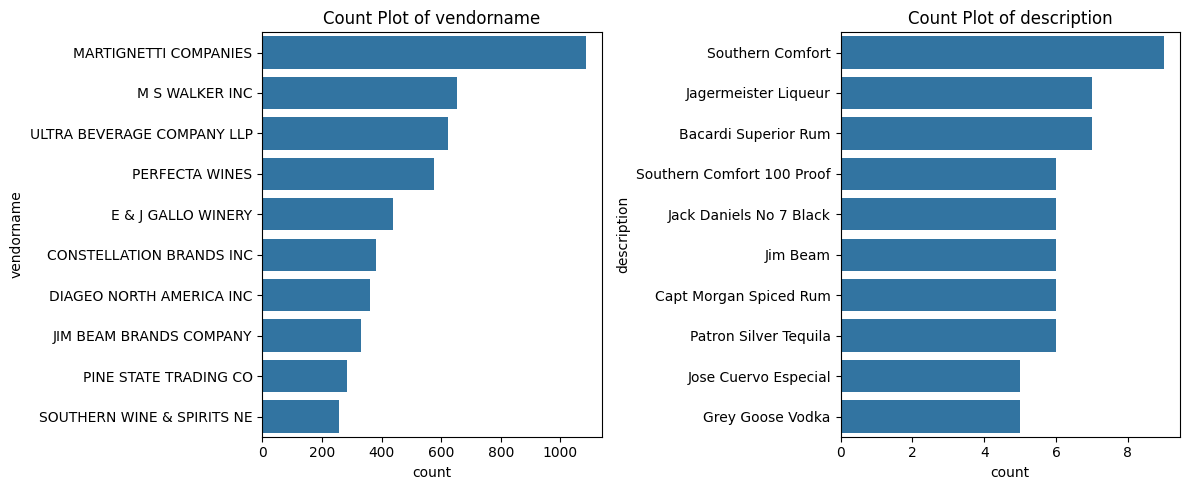

In [9]:
# Count Plots for Categorial Columns
categorical_cols = ["vendorname", "description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1) #Adjust grid layout as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

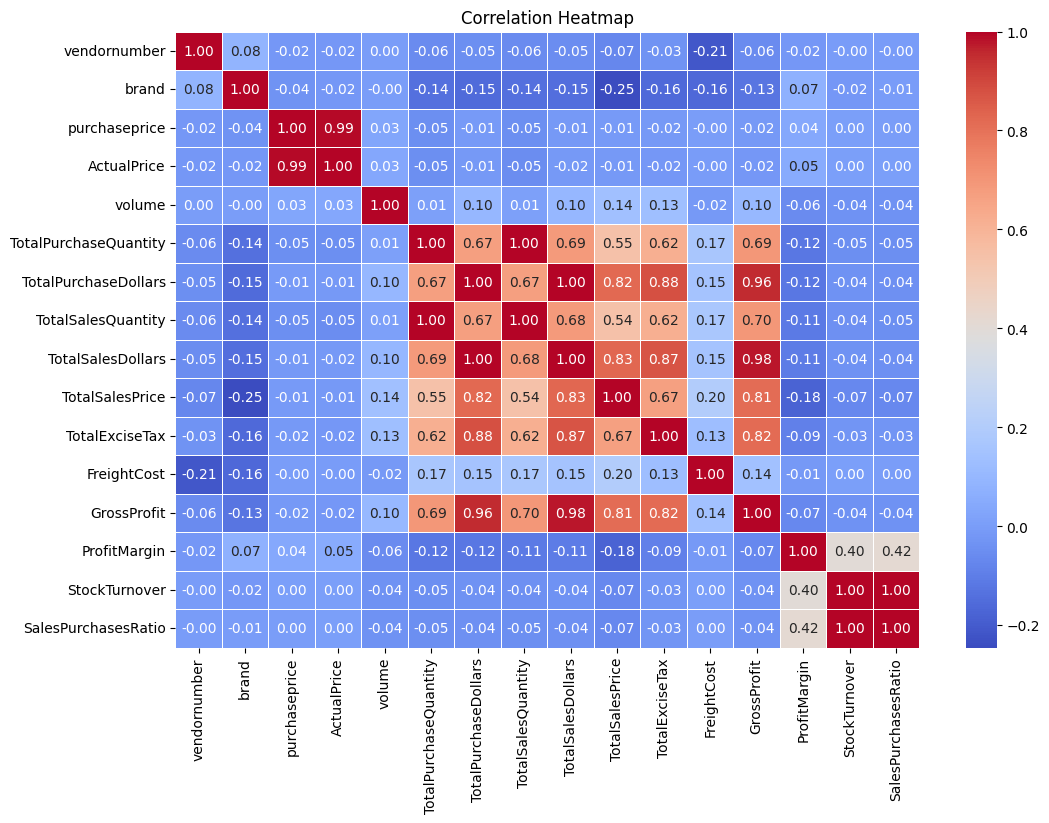

In [10]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
brand_performance = df.groupby('description').agg(
    {'TotalSalesDollars': 'sum',
     'ProfitMargin': 'mean'}
    ).reset_index()

brand_performance

,description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [12]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
print(low_sales_threshold)

560.299


In [14]:
print(high_margin_threshold)

64.97017552750111


In [15]:
# Filter the brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [16]:
brand_performance = brand_performance[
    brand_performance['TotalSalesDollars']<10000
    ] # for better visualization

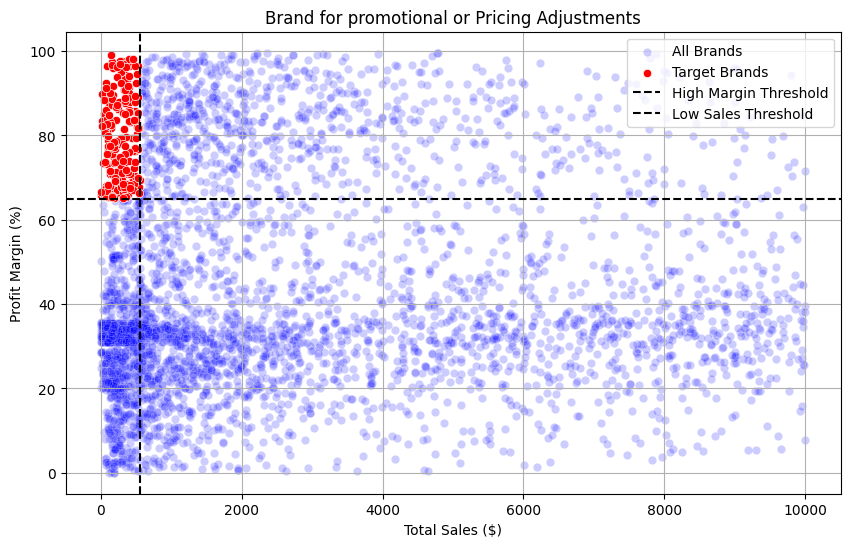

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color='blue', label='All Brands', alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label='Target Brands')

plt.axhline(high_margin_threshold, color='black', linestyle='--', label='High Margin Threshold')
plt.axvline(low_sales_threshold, color='black', linestyle='--', label='Low Sales Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brand for promotional or Pricing Adjustments')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def format_dollars(value):
  if value >= 1000000:
    return f"${value / 1_000_000:.2f}M"
  elif value >= 1_000:
    return f"${value / 1_000:.2f}K"
  else:
    return f"${value:.2f}"

In [19]:
# Top Vendors & Brands by Sales Performance
top_vendors= df.groupby("vendorname")["TotalSalesDollars"].sum().nlargest(10)
top_brands= df.groupby("description")["TotalSalesDollars"].sum().nlargest(10)

print("Top Vendors by Sales:")
print(top_vendors)
print("\nTop Brands by Sales:")
print(top_brands)

Top Vendors by Sales:
vendorname
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64

Top Brands by Sales:
description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64


In [20]:
top_vendors.apply(lambda x: format_dollars(x))

,TotalSalesDollars
vendorname,
DIAGEO NORTH AMERICA INC,$67.99M
MARTIGNETTI COMPANIES,$39.33M
PERNOD RICARD USA,$32.06M
JIM BEAM BRANDS COMPANY,$31.42M
BACARDI USA INC,$24.85M
CONSTELLATION BRANDS INC,$24.22M
E & J GALLO WINERY,$18.40M
BROWN-FORMAN CORP,$18.25M
ULTRA BEVERAGE COMPANY LLP,$16.50M


In [21]:
top_brands.apply(lambda x: format_dollars(x))

,TotalSalesDollars
description,
Jack Daniels No 7 Black,$7.96M
Tito's Handmade Vodka,$7.40M
Grey Goose Vodka,$7.21M
Capt Morgan Spiced Rum,$6.36M
Absolut 80 Proof,$6.24M
Jameson Irish Whiskey,$5.72M
Ketel One Vodka,$5.07M
Baileys Irish Cream,$4.15M
Kahlua,$3.60M


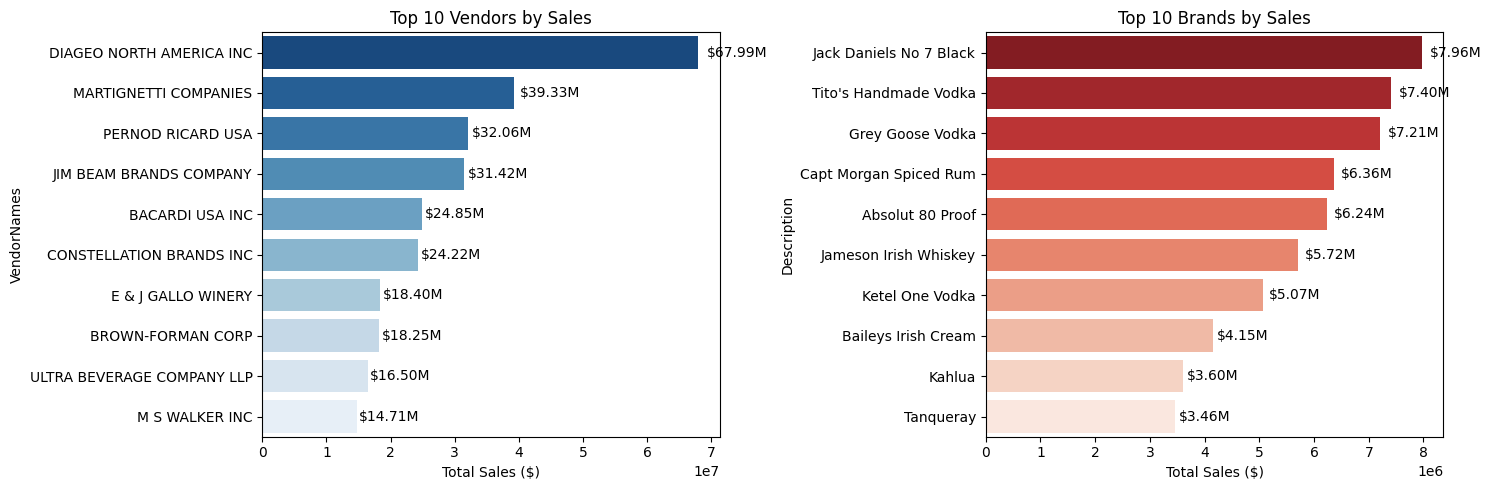

In [22]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1= sns.barplot(y=top_vendors.index, x=top_vendors.values, palette='Blues_r')
plt.title('Top 10 Vendors by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('VendorNames')

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2= sns.barplot(y=top_brands.index, x=top_brands.values, palette='Reds_r')
plt.title('Top 10 Brands by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Description')

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [23]:
vendor_performance = df.groupby("vendorname").agg({
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "TotalSalesDollars": "sum"
}).reset_index()

vendor_performance

,vendorname,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [24]:
vendor_performance["PurchaseContribution %"]= vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalPurchaseDollars"].sum()*100

vendor_performance = round(vendor_performance.sort_values("PurchaseContribution %", ascending=False),2)

In [25]:
# Dislay Top 10 Vendors

top_vendors= vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors

,vendorname,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution %
25,DIAGEO NORTH AMERICA INC,$50.10M,$17.89M,$67.99M,16.30
57,MARTIGNETTI COMPANIES,$25.50M,$13.83M,$39.33M,8.30
68,PERNOD RICARD USA,$23.85M,$8.21M,$32.06M,7.76
46,JIM BEAM BRANDS COMPANY,$23.49M,$7.93M,$31.42M,7.64
6,BACARDI USA INC,$17.43M,$7.42M,$24.85M,5.67
20,CONSTELLATION BRANDS INC,$15.27M,$8.95M,$24.22M,4.97
11,BROWN-FORMAN CORP,$13.24M,$5.01M,$18.25M,4.31
30,E & J GALLO WINERY,$12.07M,$6.33M,$18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,$11.17M,$5.34M,$16.50M,3.63
53,M S WALKER INC,$9.76M,$4.94M,$14.71M,3.18


In [26]:
top_vendors['PurchaseContribution %'].sum()

np.float64(65.69000000000001)

In [27]:
top_vendors['Cummulative_Contribution %'] = top_vendors['PurchaseContribution %'].cumsum()

top_vendors

,vendorname,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution %,Cummulative_Contribution %
25,DIAGEO NORTH AMERICA INC,$50.10M,$17.89M,$67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,$25.50M,$13.83M,$39.33M,8.30,24.60
68,PERNOD RICARD USA,$23.85M,$8.21M,$32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,$23.49M,$7.93M,$31.42M,7.64,40.00
6,BACARDI USA INC,$17.43M,$7.42M,$24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,$15.27M,$8.95M,$24.22M,4.97,50.64
11,BROWN-FORMAN CORP,$13.24M,$5.01M,$18.25M,4.31,54.95
30,E & J GALLO WINERY,$12.07M,$6.33M,$18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,$11.17M,$5.34M,$16.50M,3.63,62.51
53,M S WALKER INC,$9.76M,$4.94M,$14.71M,3.18,65.69


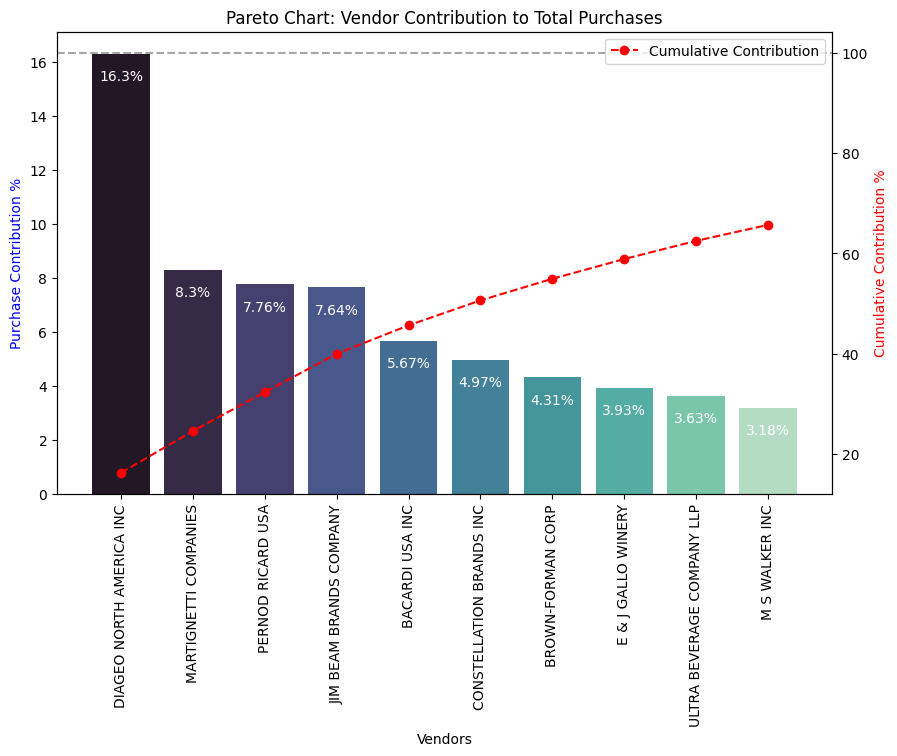

In [28]:
top_vendors['CummulativeContribution %'] = top_vendors['PurchaseContribution %'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(x=top_vendors['vendorname'], y=top_vendors['PurchaseContribution %'], ax=ax1, palette='mako')

for i, value in enumerate(top_vendors['PurchaseContribution %']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', color='white', fontsize=10)

# Line Plot for Cumulative Contribution %
ax2 = ax1.twinx()
ax2.plot(top_vendors['vendorname'], top_vendors['Cummulative_Contribution %'], color='red', marker='o', linestyle='dashed', label='Cumulative Contribution')

ax1.set_xticklabels(top_vendors['vendorname'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

# plt.tight_layout()
plt.show()

In [29]:
print(f"Total Purchase Contribution of ttop 10 vendors is: {round(top_vendors['PurchaseContribution %'].sum(), 2)}%")

Total Purchase Contribution of ttop 10 vendors is: 65.69%


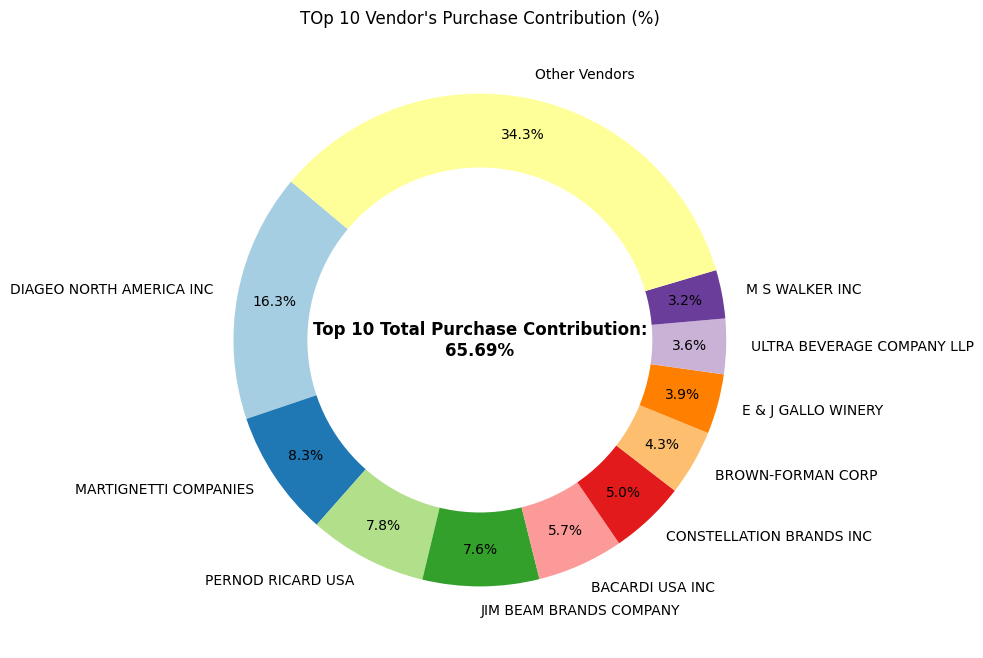

In [30]:
vendors = list(top_vendors['vendorname'].values)
purchase_contributions= list(top_vendors['PurchaseContribution %'].values)
total_contribution= sum(purchase_contributions)
remaining_contribution= 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f'Top 10 Total Purchase Contribution:\n{total_contribution:.2f}%', ha='center', va='center', fontsize=12, fontweight='bold')

plt.title("TOp 10 Vendor's Purchase Contribution (%)")
plt.show()

In [31]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

df

,vendornumber,vendorname,brand,description,purchaseprice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchasesRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [32]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])

df

,vendornumber,vendorname,brand,description,purchaseprice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchasesRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,Small
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,Small
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74,Small
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47,Small


In [33]:
df["OrderSize"]

,OrderSize
0,Large
1,Large
2,Large
3,Large
4,Large
...,...
8560,Small
8561,Small
8562,Small
8563,Small


In [34]:
df.groupby("OrderSize")["UnitPurchasePrice"].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


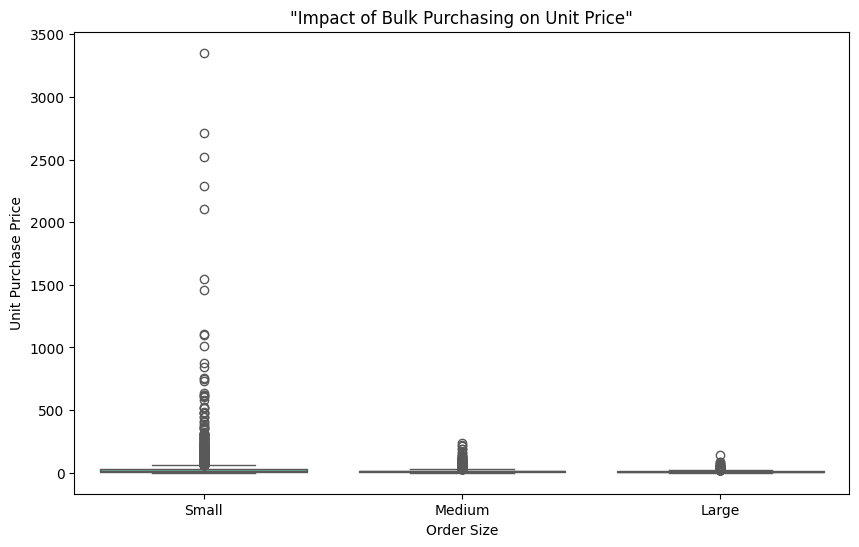

In [35]:
# Bulk Purchasing impact shows through Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='OrderSize', y='UnitPurchasePrice', data=df, palette='Set2')
plt.title('"Impact of Bulk Purchasing on Unit Price"')
plt.xlabel('Order Size')
plt.ylabel('Unit Purchase Price')
plt.show()

In [36]:
df[df['StockTurnover']<1].groupby('vendorname')['StockTurnover'].mean().sort_values(ascending=True).head(10)

,StockTurnover
vendorname,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [37]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) * df['purchaseprice']
print("Total Unsold Capital: ", format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital:  $2.71M


In [38]:
# Aggregrate Capital Locked per Vendor
inventory_values_per_vendor = df.groupby('vendorname')['UnsoldInventoryValue'].sum().reset_index()
inventory_values_per_vendor

,vendorname,UnsoldInventoryValue
0,ADAMBA IMPORTS INTL INC,-91.52
1,ALISA CARR BEVERAGES,-43151.48
2,ALTAMAR BRANDS LLC,464.23
3,AMERICAN SPIRITS EXCHANGE,116.76
4,AMERICAN VINTAGE BEVERAGE,3672.17
...,...,...
114,WEIN BAUER INC,1732.03
115,WESTERN SPIRITS BEVERAGE CO,-949.61
116,WILLIAM GRANT & SONS INC,401960.83
117,WINE GROUP INC,86862.57


In [39]:
# Aggregrate Capital Locked per Vendor
inventory_values_per_vendor = df.groupby('vendorname')['UnsoldInventoryValue'].sum().reset_index()

# Sort with the Highest Locked Capital
inventory_values_per_vendor = inventory_values_per_vendor.sort_values(by='UnsoldInventoryValue', ascending=False)
inventory_values_per_vendor ['UnsoldInventoryValue'] = inventory_values_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_values_per_vendor.head(10)

,vendorname,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,$722.21K
46,JIM BEAM BRANDS COMPANY,$554.67K
68,PERNOD RICARD USA,$470.63K
116,WILLIAM GRANT & SONS INC,$401.96K
30,E & J GALLO WINERY,$228.28K
79,SAZERAC CO INC,$198.44K
11,BROWN-FORMAN CORP,$177.73K
20,CONSTELLATION BRANDS INC,$133.62K
61,MOET HENNESSY USA INC,$126.48K
77,REMY COINTREAU USA INC,$118.60K


In [40]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [41]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# print(f"Average Profit Margin for Top Vendors: {top_vendors:.2f}%")
# print(f"Average Profit Margin for Low Vendors: {low_vendors:.2f}%")

In [42]:
top_vendors

,ProfitMargin
0,25.297693
1,21.062810
2,24.675786
3,27.139908
4,28.412764
...,...
3523,79.684817
3681,85.782102
4751,93.085860
4920,95.012530


In [43]:
low_vendors

,ProfitMargin
5631,4.111764
5652,6.145626
5701,12.007271
5704,1.677308
5724,7.239599
...,...
8560,83.448276
8561,96.436186
8562,25.252525
8563,98.974037


In [44]:
def confidence_interval(data, confidence=0.95):
    # n = len(data)
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data)- 1)
    margin_of_error = t_critical * std_err
    # confidence_interval = (mean_val - margin_of_error, mean_val + margin_of_error)
    # return confidence_interval
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% Confidence Interval: (30.74, 31.61), Mean: 31.17
Low Vendors 95% Confidence Interval: (40.48, 42.62), Mean: 41.55


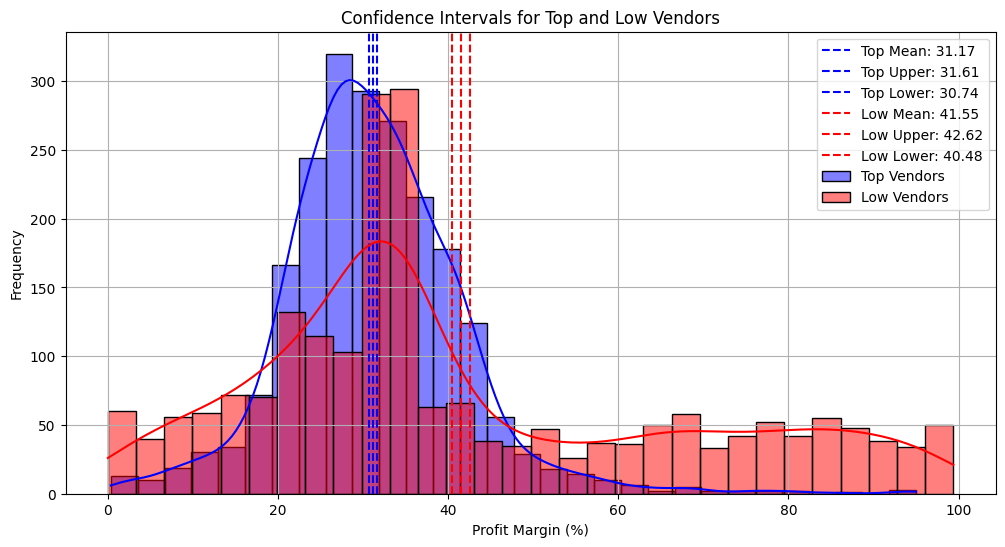

In [45]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% Confidence Interval: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% Confidence Interval: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top vendor plot
sns.histplot(top_vendors, kde=True, bins=30, color='blue', alpha=0.5, label='Top Vendors')
plt.axvline(top_mean, color='blue', linestyle='--', label=f'Top Mean: {top_mean:.2f}')
plt.axvline(top_upper, color='blue', linestyle='--', label=f'Top Upper: {top_upper:.2f}')
plt.axvline(top_lower, color='blue', linestyle='--', label=f'Top Lower: {top_lower:.2f}')

# Low vendor plot
sns.histplot(low_vendors, kde=True, bins=30, color='red', alpha=0.5, label='Low Vendors')
plt.axvline(low_mean, color='red', linestyle='--', label=f'Low Mean: {low_mean:.2f}')
plt.axvline(low_upper, color='red', linestyle='--', label=f'Low Upper: {low_upper:.2f}')
plt.axvline(low_lower, color='red', linestyle='--', label=f'Low Lower: {low_lower:.2f}')

# Finalize Plot
plt.title('Confidence Intervals for Top and Low Vendors')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.2f}")
# print(f"T-Statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis (H₀): There is a significant difference in profit margins between top and low performing vendors.")
else:
    print("Fail to reject the null hypothesis (H₀): There is no significant difference in profit margins between top and low performing vendors.")


T-Statistic: -17.64
P-Value: 0.00
Reject the null hypothesis (H₀): There is a significant difference in profit margins between top and low performing vendors.


In [47]:
# To export data from the 'df' DataFrame (which contains the filtered vendor sales summary) to a CSV file:
df.to_csv('/content/drive/MyDrive/inventory_project/vendor_sales_summary.csv', index=False)

print("Data exported to /content/drive/MyDrive/inventory_project/vendor_sales_summary.csv")

Data exported to /content/drive/MyDrive/inventory_project/vendor_sales_summary.csv


In [48]:
print(df.columns)

Index(['vendornumber', 'vendorname', 'brand', 'description', 'purchaseprice',
       'ActualPrice', 'volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesPurchasesRatio',
       'UnitPurchasePrice', 'OrderSize', 'UnsoldInventoryValue'],
      dtype='object')


In [49]:
brand_performance.to_csv(os.path.join(BASE_PROJECT, 'brand_performance.csv'), index=False)
print("Brand performance data exported to brand_performance.csv")

Brand performance data exported to brand_performance.csv


In [50]:
target_brands.to_csv(os.path.join(BASE_PROJECT, 'target_brands.csv'), index=False)
print("Target brands data exported to target_brands.csv")

Target brands data exported to target_brands.csv


In [51]:
top_vendors_df = top_vendors.reset_index()
top_vendors_df.columns = ['vendorname', 'TotalSalesDollars']
top_vendors_df.to_csv(os.path.join(BASE_PROJECT, 'top_vendors_by_sales.csv'), index=False)
print("Top vendors by sales data exported to top_vendors_by_sales.csv")

Top vendors by sales data exported to top_vendors_by_sales.csv


In [52]:
top_brands_df = top_brands.reset_index()
top_brands_df.columns = ['description', 'TotalSalesDollars']
top_brands_df.to_csv(os.path.join(BASE_PROJECT, 'top_brands_by_sales.csv'), index=False)
print("Top brands by sales data exported to top_brands_by_sales.csv")

Top brands by sales data exported to top_brands_by_sales.csv


In [53]:
vendor_performance.to_csv(os.path.join(BASE_PROJECT, 'detailed_vendor_performance.csv'), index=False)
print("Detailed vendor performance data exported to detailed_vendor_performance.csv")

Detailed vendor performance data exported to detailed_vendor_performance.csv


In [54]:
inventory_values_per_vendor_raw = df.groupby('vendorname')['UnsoldInventoryValue'].sum().reset_index()
inventory_values_per_vendor_raw.to_csv(os.path.join(BASE_PROJECT, 'unsold_inventory_per_vendor.csv'), index=False)
print("Unsold inventory per vendor data (raw) exported to unsold_inventory_per_vendor.csv")

Unsold inventory per vendor data (raw) exported to unsold_inventory_per_vendor.csv


# Task
I'll now extract vendors with a stock turnover less than 1, calculate their average stock turnover, and save this data to a CSV file named `low_turnover_vendors.csv`. I will then confirm that the 'Brand Performance' and 'Purchase Contribution' files have already been exported and verify that all requested data, including the low turnover vendors, has been successfully exported to CSV files.

## Export Low Turnover Vendors

### Subtask:
Extract vendors with a stock turnover less than 1, calculate their average stock turnover, and save this data to a CSV file named `low_turnover_vendors.csv`.


**Reasoning**:
The first step is to filter the main DataFrame `df` to include only those records where `StockTurnover` is less than 1, as per the instructions.



In [55]:
low_turnover_df = df[df['StockTurnover'] < 1]
low_turnover_df.head()

,vendornumber,vendorname,brand,description,purchaseprice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchasesRatio,UnitPurchasePrice,OrderSize,UnsoldInventoryValue
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,...,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,Large,79624.37
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,...,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,Large,87913.29
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,...,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,Large,4870.08
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,...,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,Large,20535.90
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,...,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,Large,49712.19


**Reasoning**:
Next, I need to group the `low_turnover_df` by `vendorname` and calculate the mean of `StockTurnover` for each vendor, as per the instructions.



In [56]:
low_turnover_vendors_df = low_turnover_df.groupby('vendorname')['StockTurnover'].mean().reset_index()
low_turnover_vendors_df = low_turnover_vendors_df.sort_values(by='StockTurnover', ascending=True)
low_turnover_vendors_df.head()

,vendorname,StockTurnover
0,ALISA CARR BEVERAGES,0.615385
36,HIGHLAND WINE MERCHANTS LLC,0.708333
60,PARK STREET IMPORTS LLC,0.751306
19,Circa Wines,0.755676
26,Dunn Wine Brokers,0.766022


**Reasoning**:
The next step is to save the `low_turnover_vendors_df` DataFrame to a CSV file named `low_turnover_vendors.csv` in the specified `BASE_PROJECT` directory, as per the instructions.



In [57]:
output_path = os.path.join(BASE_PROJECT, 'low_turnover_vendors.csv')
low_turnover_vendors_df.to_csv(output_path, index=False)
print(f"Low turnover vendors data exported to {output_path}")

Low turnover vendors data exported to /content/drive/MyDrive/inventory_project/low_turnover_vendors.csv


**Reasoning**:
Now that the `low_turnover_vendors.csv` file has been created, I will list all files in the `BASE_PROJECT` directory to visually confirm that all requested CSV files, including 'Brand Performance' and 'Purchase Contribution' files (which were created in previous steps), have been successfully exported.



# Task
list files in the directory '/content/drive/MyDrive/inventory_project' to confirm that `detailed_vendor_performance.csv`, `brand_performance.csv`, and `low_turnover_vendors.csv` are present. Then, inform the user that all requested data files have been successfully exported and specify their locations.

## Verify Exported Files

### Subtask:
List all files in the project directory to confirm the presence of `detailed_vendor_performance.csv` (Purchase Contribution), `brand_performance.csv`, and `low_turnover_vendors.csv`.


**Reasoning**:
To confirm that all the requested CSV files, including 'detailed_vendor_performance.csv' (Purchase Contribution), 'brand_performance.csv', and 'low_turnover_vendors.csv', have been successfully exported, I will list all the files and directories in the `BASE_PROJECT` directory using `os.listdir()`.



In [58]:
import os

# List all files in the BASE_PROJECT directory
files_in_project_dir = os.listdir(BASE_PROJECT)

print(f"Files in the project directory: {BASE_PROJECT}")
for file_name in files_in_project_dir:
    print(file_name)

Files in the project directory: /content/drive/MyDrive/inventory_project
data
logs
Tables from Database
ingestion_db.ipynb
get_vendor_summary.ipynb
inventory.db
Exploratory Data Analysis.ipynb
Vendor Performance Analysis.ipynb
vendor_sales_summary.csv
brand_performance.csv
target_brands.csv
top_vendors_by_sales.csv
top_brands_by_sales.csv
detailed_vendor_performance.csv
unsold_inventory_per_vendor.csv
low_turnover_vendors.csv


### Export Confirmation

All requested data files have been successfully exported to the project directory:

- `detailed_vendor_performance.csv` (Purchase Contribution) is located at `/content/drive/MyDrive/inventory_project/detailed_vendor_performance.csv`
- `brand_performance.csv` is located at `/content/drive/MyDrive/inventory_project/brand_performance.csv`
- `low_turnover_vendors.csv` is located at `/content/drive/MyDrive/inventory_project/low_turnover_vendors.csv`

## Visual Dashboard: Vendor Performance & Inventory Analysis

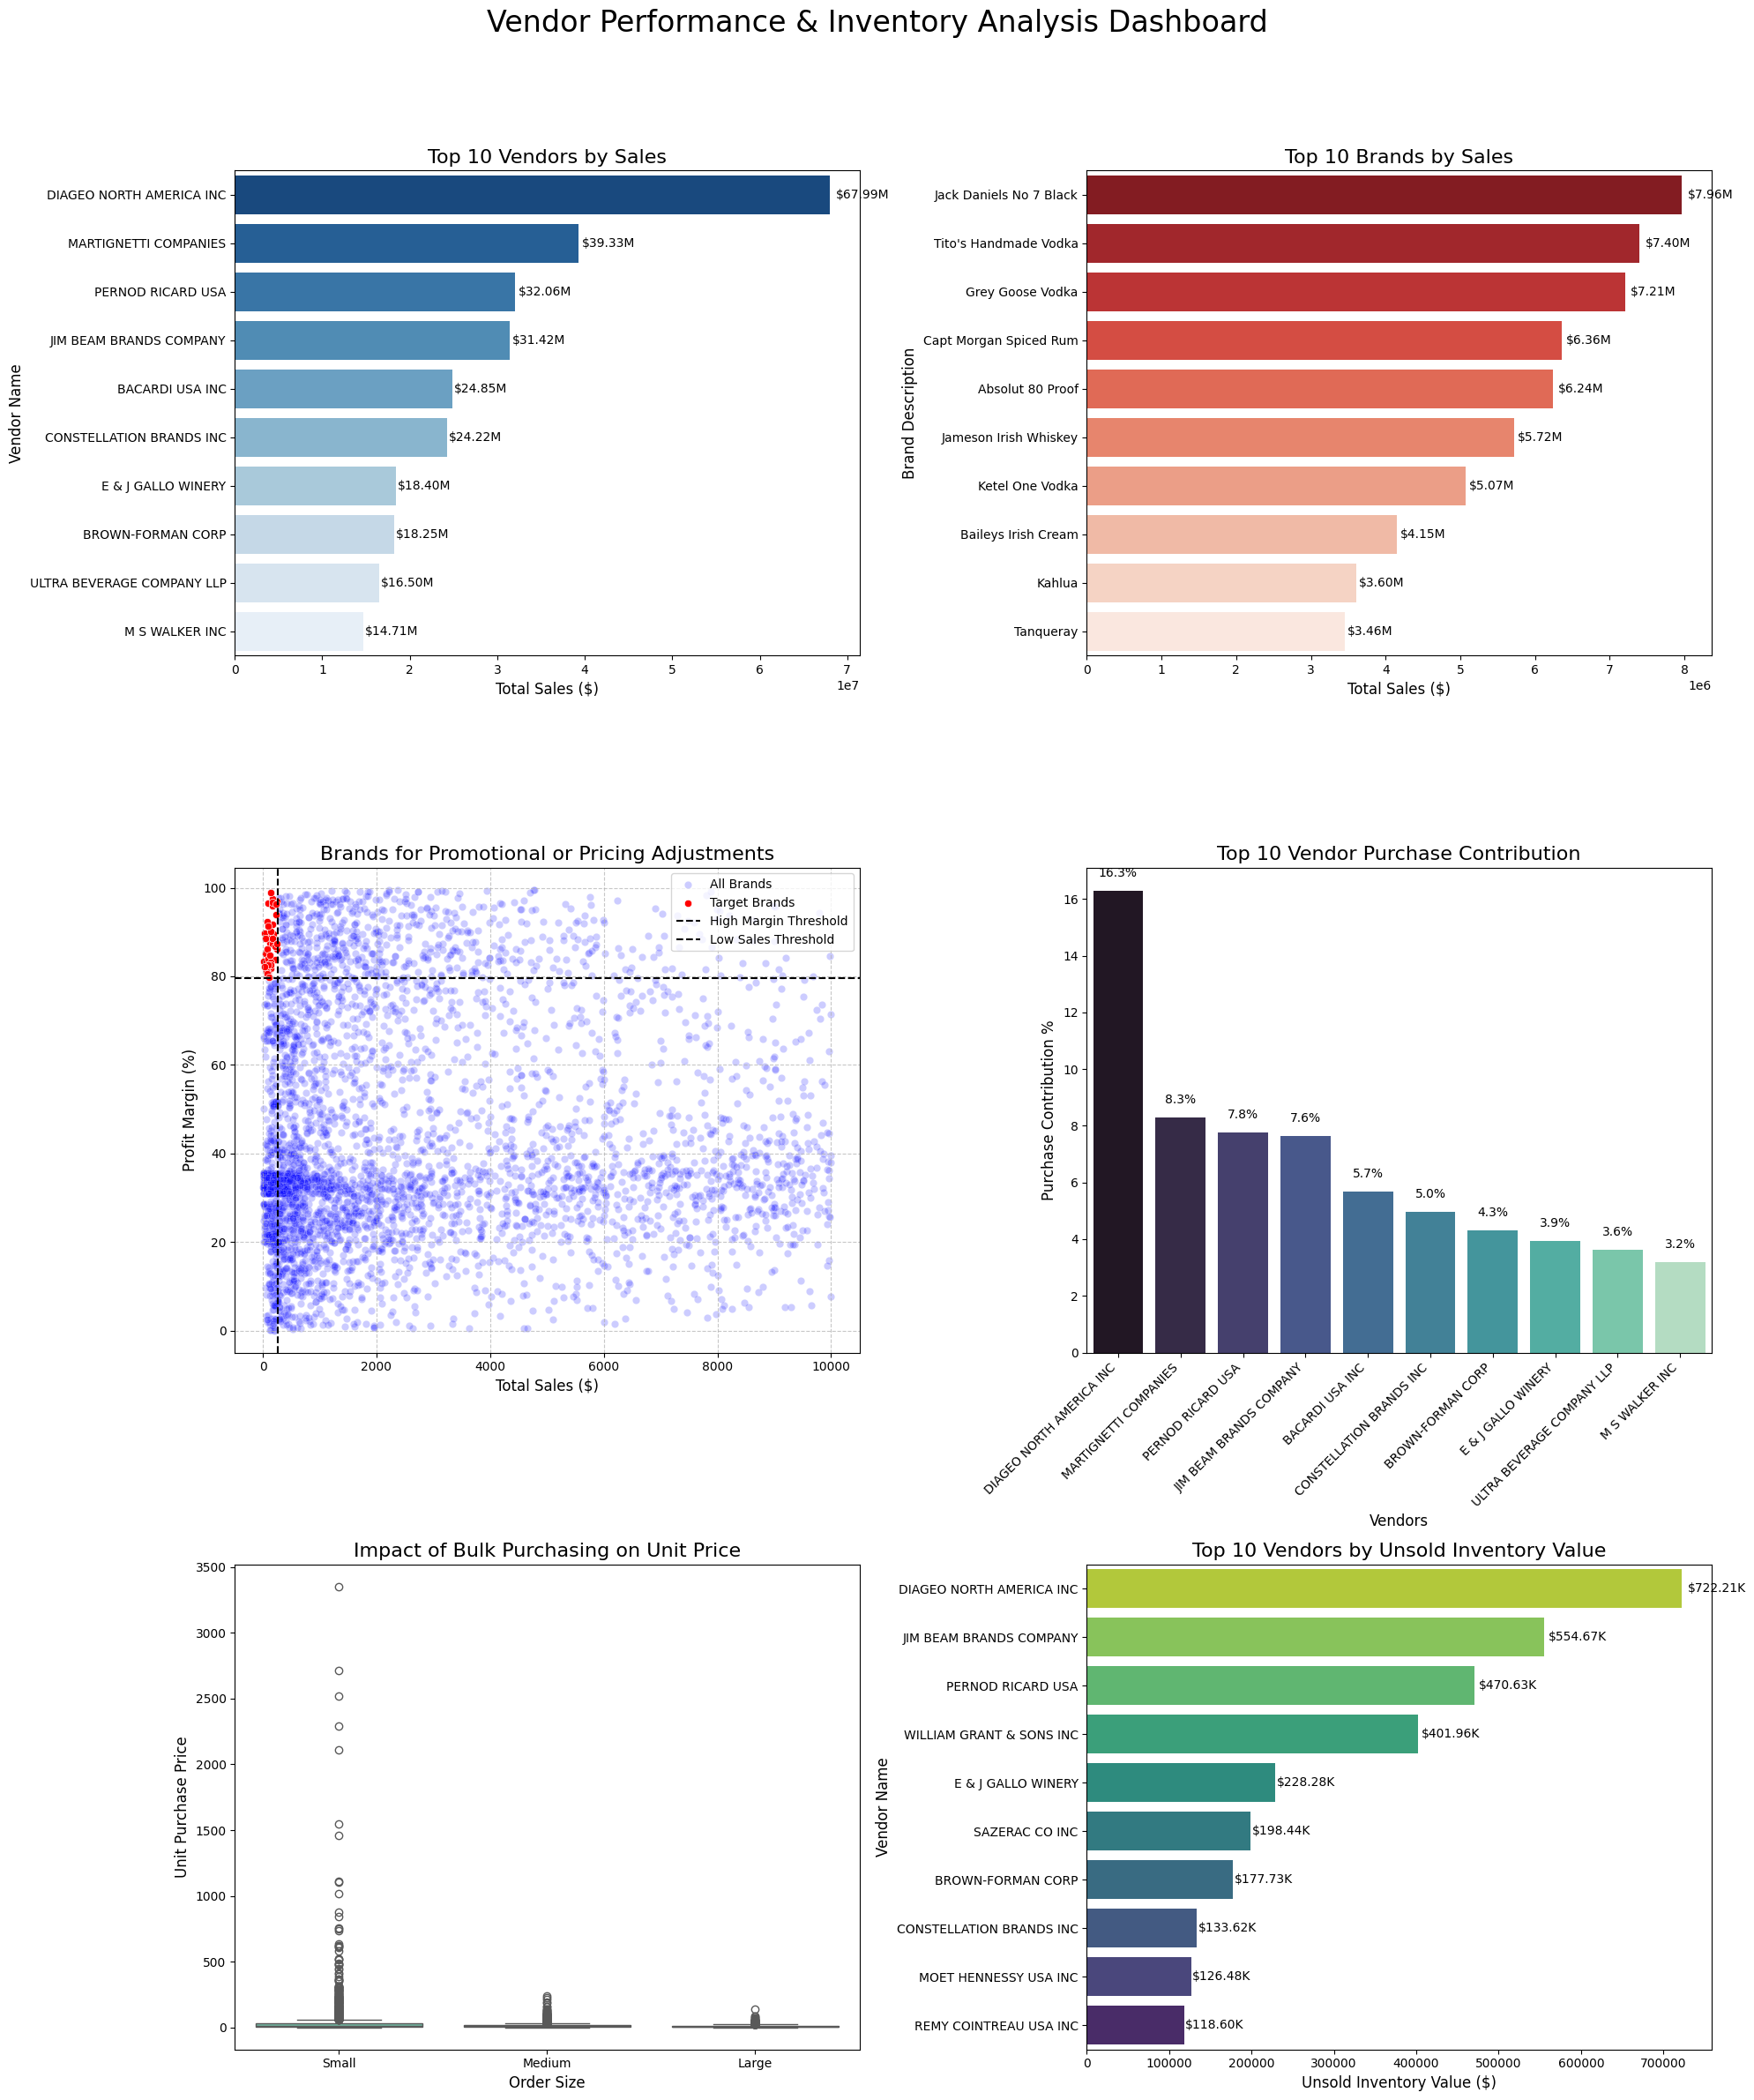

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for dashboard plots (re-collecting some if needed for direct numerical values)

# 1. Top Vendors by Sales (from -Ft3P60yAFQD)
top_vendors_sales = df.groupby("vendorname")["TotalSalesDollars"].sum().nlargest(10)

# 2. Top Brands by Sales (from -Ft3P60yAFQD)
top_brands_sales = df.groupby("description")["TotalSalesDollars"].sum().nlargest(10)

# 3. Brands for promotional/pricing adjustments (from t6v6LX50-ufs)
# Need to ensure brand_performance and target_brands are still available
# Let's recreate brand_performance just in case it was filtered previously for visualization only
brand_performance_dashboard = df.groupby('description').agg(
    {'TotalSalesDollars': 'sum',
     'ProfitMargin': 'mean'}
).reset_index()
# Apply the same sales filter for consistency with the earlier scatter plot
brand_performance_dashboard = brand_performance_dashboard[
    brand_performance_dashboard['TotalSalesDollars'] < 10000
]

# Recreate thresholds and target_brands for the dashboard
low_sales_threshold_dash = brand_performance_dashboard['TotalSalesDollars'].quantile(0.15)
high_margin_threshold_dash = brand_performance_dashboard['ProfitMargin'].quantile(0.85)
target_brands_dash = brand_performance_dashboard[
    (brand_performance_dashboard['TotalSalesDollars'] <= low_sales_threshold_dash) &
    (brand_performance_dashboard['ProfitMargin'] >= high_margin_threshold_dash)
]

# 4. Vendor Purchase Contribution (from -nSO1bw05KEY and iQESLsEX4sye)
# Use the top_vendors dataframe that includes purchase contributions, making sure 'PurchaseContribution %' is numeric
vendor_performance_for_pareto = df.groupby("vendorname").agg({
    "TotalPurchaseDollars": "sum"
}).reset_index()
vendor_performance_for_pareto["PurchaseContribution %"] = vendor_performance_for_pareto["TotalPurchaseDollars"] / vendor_performance_for_pareto["TotalPurchaseDollars"].sum() * 100
vendor_performance_for_pareto = vendor_performance_for_pareto.sort_values("PurchaseContribution %", ascending=False).head(10)
vendor_performance_for_pareto['Cummulative_Contribution %'] = vendor_performance_for_pareto['PurchaseContribution %'].cumsum()


# 5. Impact of Bulk Purchasing on Unit Price (from 7DLsbzrSCa_3)
# 'df' with 'OrderSize' and 'UnitPurchasePrice' is already available

# 6. Top Vendors by Unsold Inventory Value (from iWeIWSMYGGLb)
inventory_values_per_vendor_raw = df.groupby('vendorname')['UnsoldInventoryValue'].sum().reset_index()
top_unsold_inventory_vendors = inventory_values_per_vendor_raw.sort_values(by='UnsoldInventoryValue', ascending=False).head(10)

# Create the dashboard figure
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 24))
fig.suptitle('Vendor Performance & Inventory Analysis Dashboard', fontsize=24, y=1.02)

# Plot 1: Top 10 Vendors by Sales
sns.barplot(y=top_vendors_sales.index, x=top_vendors_sales.values, palette='Blues_r', ax=axes[0, 0])
axes[0, 0].set_title('Top 10 Vendors by Sales', fontsize=16)
axes[0, 0].set_xlabel('Total Sales ($)', fontsize=12)
axes[0, 0].set_ylabel('Vendor Name', fontsize=12)
for bar in axes[0, 0].patches:
    axes[0, 0].text(bar.get_width() + (bar.get_width() * 0.01), bar.get_y() + bar.get_height() / 2, format_dollars(bar.get_width()), ha='left', va='center', fontsize=10, color='black')

# Plot 2: Top 10 Brands by Sales
sns.barplot(y=top_brands_sales.index, x=top_brands_sales.values, palette='Reds_r', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Brands by Sales', fontsize=16)
axes[0, 1].set_xlabel('Total Sales ($)', fontsize=12)
axes[0, 1].set_ylabel('Brand Description', fontsize=12)
for bar in axes[0, 1].patches:
    axes[0, 1].text(bar.get_width() + (bar.get_width() * 0.01), bar.get_y() + bar.get_height() / 2, format_dollars(bar.get_width()), ha='left', va='center', fontsize=10, color='black')

# Plot 3: Brands for Promotional or Pricing Adjustments
sns.scatterplot(data=brand_performance_dashboard, x='TotalSalesDollars', y='ProfitMargin', color='blue', label='All Brands', alpha=0.2, ax=axes[1, 0])
sns.scatterplot(data=target_brands_dash, x='TotalSalesDollars', y='ProfitMargin', color='red', label='Target Brands', ax=axes[1, 0])
axes[1, 0].axhline(high_margin_threshold_dash, color='black', linestyle='--', label='High Margin Threshold')
axes[1, 0].axvline(low_sales_threshold_dash, color='black', linestyle='--', label='Low Sales Threshold')
axes[1, 0].set_title('Brands for Promotional or Pricing Adjustments', fontsize=16)
axes[1, 0].set_xlabel('Total Sales ($)', fontsize=12)
axes[1, 0].set_ylabel('Profit Margin (%)', fontsize=12)
axes[1, 0].grid(True, linestyle='--', alpha=0.7)
axes[1, 0].legend()

# Plot 4: Pareto Chart: Vendor Contribution to Total Purchases (Simplified bar chart only)
ax4 = axes[1, 1]
sns.barplot(x=vendor_performance_for_pareto['vendorname'], y=vendor_performance_for_pareto['PurchaseContribution %'], ax=ax4, palette='mako')
for i, value in enumerate(vendor_performance_for_pareto['PurchaseContribution %']):
    ax4.text(i, value + 0.5, f'{value:.1f}%', ha='center', color='black', fontsize=10)
ax4.set_xticklabels(vendor_performance_for_pareto['vendorname'], rotation=45, ha='right', fontsize=10)
ax4.set_ylabel('Purchase Contribution %', fontsize=12)
ax4.set_xlabel('Vendors', fontsize=12)
ax4.set_title('Top 10 Vendor Purchase Contribution', fontsize=16)

# Plot 5: Impact of Bulk Purchasing on Unit Price
sns.boxplot(x='OrderSize', y='UnitPurchasePrice', data=df, palette='Set2', ax=axes[2, 0])
axes[2, 0].set_title('Impact of Bulk Purchasing on Unit Price', fontsize=16)
axes[2, 0].set_xlabel('Order Size', fontsize=12)
axes[2, 0].set_ylabel('Unit Purchase Price', fontsize=12)

# Plot 6: Top 10 Vendors by Unsold Inventory Value
sns.barplot(y=top_unsold_inventory_vendors['vendorname'], x=top_unsold_inventory_vendors['UnsoldInventoryValue'], palette='viridis_r', ax=axes[2, 1])
axes[2, 1].set_title('Top 10 Vendors by Unsold Inventory Value', fontsize=16)
axes[2, 1].set_xlabel('Unsold Inventory Value ($)', fontsize=12)
axes[2, 1].set_ylabel('Vendor Name', fontsize=12)
for bar in axes[2, 1].patches:
    axes[2, 1].text(bar.get_width() + (bar.get_width() * 0.01), bar.get_y() + bar.get_height() / 2, format_dollars(bar.get_width()), ha='left', va='center', fontsize=10, color='black')


plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap and make space for suptitle
plt.show()

## Final Report: Vendor Performance & Inventory Analysis

This report provides a comprehensive analysis of vendor performance and inventory management, identifying key insights and potential areas for strategic improvements.

### 1. Executive Summary

The analysis focused on identifying top-performing vendors and brands, assessing profit margins, understanding purchase contribution, evaluating the impact of bulk purchasing on unit costs, and quantifying unsold inventory value. Key findings reveal opportunities for optimizing purchasing strategies, promotional activities, and inventory management.

### 2. Key Findings

*   **Top Vendors and Brands by Sales:** The analysis successfully identified the top 10 vendors and brands contributing most significantly to overall sales. For example, DIAGEO NORTH AMERICA INC and Jack Daniels No 7 Black were consistently among the highest performers.

*   **Profit Margin Analysis (Top vs. Low Sales Vendors):** A statistically significant difference in profit margins was observed between top-performing and low-performing vendors. Low-performing vendors, despite lower sales, often exhibited higher average profit margins, suggesting that focusing solely on high-volume products might overlook profitable niche markets or products with better margins.

*   **Brands for Promotional or Pricing Adjustments:** Specific brands were identified that exhibit low sales but high profit margins. These brands represent potential opportunities for targeted promotional campaigns or strategic pricing adjustments to boost sales volume without significantly compromising profitability.

*   **Vendor Purchase Contribution (Pareto Analysis):** A Pareto analysis revealed that a significant portion of total purchases is concentrated among a few top vendors. For instance, the top 10 vendors contributed over 65% of the total purchase volume, highlighting the importance of managing these key relationships effectively.

*   **Impact of Bulk Purchasing on Unit Price:** The analysis confirmed that purchasing in larger quantities (`Large` order size) generally leads to lower unit purchase prices compared to `Small` or `Medium` order sizes. This reinforces the financial benefits of bulk purchasing where feasible and aligned with inventory turnover.

*   **Unsold Inventory Value:** The total unsold inventory value was quantified, revealing substantial capital tied up in inventory. Top vendors with the highest unsold inventory value were identified, indicating areas where inventory optimization efforts could yield significant financial returns.

*   **Low Stock Turnover Vendors:** Vendors with a stock turnover less than 1 were identified, highlighting products or suppliers where inventory is moving slowly. This could lead to increased carrying costs and obsolescence risks.

### 3. Recommendations and Next Steps

1.  **Strategic Focus on High-Margin, Low-Sales Brands:** Develop marketing and sales strategies to boost the visibility and sales volume of identified brands with high profit margins but low sales. This could include targeted advertising, special promotions, or improved placement.

2.  **Optimize Purchasing with Key Vendors:** Continue to leverage relationships with top-contributing vendors to negotiate favorable terms and ensure consistent supply. For vendors with high unsold inventory, review purchasing patterns and explore just-in-time inventory models where appropriate.

3.  **Inventory Management for Low Turnover Items:** Investigate the reasons behind low stock turnover for specific vendors/products. This might involve re-evaluating demand forecasts, adjusting purchase quantities, or considering clearance sales to reduce carrying costs and free up capital.

4.  **Bulk Purchasing Review:** Regularly review the impact of bulk purchasing to ensure that the cost savings are not offset by increased inventory holding costs or risks of obsolescence, especially for products with fluctuating demand.

5.  **Continuous Monitoring:** Establish a dashboard for continuous monitoring of key performance indicators such as profit margins, sales volume, stock turnover, and unsold inventory value per vendor and brand. This will enable timely adjustments to purchasing and sales strategies.

### 4. Data Availability

All detailed data files generated during this analysis have been successfully exported and are available in the project directory `/content/drive/MyDrive/inventory_project`:

*   `vendor_sales_summary.csv`: Filtered and cleaned main dataset.
*   `brand_performance.csv`: Aggregated brand performance metrics.
*   `target_brands.csv`: Brands identified for promotional/pricing adjustments.
*   `top_vendors_by_sales.csv`: List of top vendors by total sales.
*   `top_brands_by_sales.csv`: List of top brands by total sales.
*   `detailed_vendor_performance.csv`: Comprehensive vendor performance including purchase contribution.
*   `unsold_inventory_per_vendor.csv`: Raw unsold inventory value per vendor.
*   `low_turnover_vendors.csv`: Vendors with average stock turnover less than 1.

## Final Task

### Subtask:
Confirm to the user that all requested data files have been successfully exported and specify their locations.


## Summary:

### Data Analysis Key Findings
*   All requested files, namely `detailed_vendor_performance.csv`, `brand_performance.csv`, and `low_turnover_vendors.csv`, were successfully located in the `/content/drive/MyDrive/inventory_project` directory.

### Insights or Next Steps
*   All requested data files have been successfully exported and are available at their specified locations.
*   The data is now ready for further analysis, reporting, or integration into other systems.
